# `dippa.profiles` walkthrough

This notebook does two jobs:

1. **A manual sanity check while developing** — rerun this after changing
   anything in `profiles.py` and eyeball the plots; catches obviously wrong
   changes faster than digging through `pytest -v` output.
2. **A first example for users**, once the API stabilises — this is the
   easiest way to see what the peak-shape functions actually produce.

Status: pre-alpha. This notebook only covers the profile/peak-shape
functions — the fitter has its own walkthrough in
`02_fitting_walkthrough.ipynb`, and `AGENTS.md`/`TODO.md` track what's
next. Nothing here should be used for real analysis.

## Profile maths implemented here

For $\Delta x=x-x_0$, `pseudo_voigt` evaluates

$$pV(x)=A\left[\eta L(x)+(1-\eta)G(x)\right],$$

$$G(x)=\exp\!\left[-4\ln 2\,\frac{(x-x_0)^2}{fw^2}\right],\qquad
L(x)=\frac{1}{1+4(x-x_0)^2/fw^2}.$$

The code preserves the original MATLAB literal and computes the Gaussian as
`exp(-((x-x0)/(0.600561*fw))**2)`; $0.600561 \approx 1/(2\sqrt{\ln 2})$.
Thus $A$ (`amplitude`) is the peak height: both $G(x_0)$ and $L(x_0)$ are one.
$fw$ is the FWHM, and $\eta$ is the mixing parameter: 0 is Gaussian, 1 is
Lorentzian, and values above 1 are the original tool's super-Lorentzian extension.

The asymmetric function is the same expression on each side of $x_0$, using
$(fw_{left},\eta_{left})$ for $x<x_0$ and
$(fw_{right},\eta_{right})$ for $x\ge x_0$. Its canonical array order is
`[x0, amplitude, fwhm_right, eta_left, fwhm_left, eta_right]`.

For a named X-ray tube, `evaluate_peak` adds a second evaluation with height
$A/2$ and centre

$$x_{0,2}=x_0+x_0\frac{\lambda_2-\lambda_1}{(\lambda_1+\lambda_2)/2},$$

leaving every width and mixing parameter unchanged. `tube=None` returns only
the first component. This displacement is specifically for $g=1/d$ in Å$^{-1}$.

## 1. A single symmetric peak

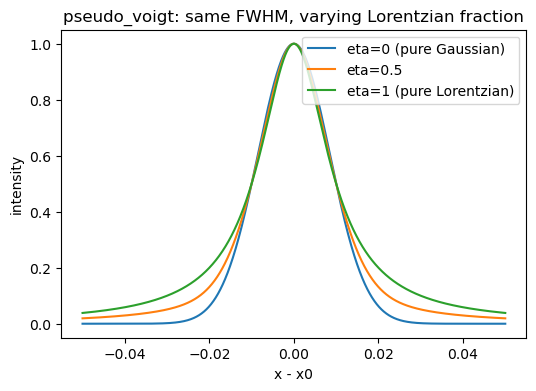

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from dippa.profiles import pseudo_voigt, asymmetric_pseudo_voigt, evaluate_peak, evaluate_pattern

x = np.linspace(-0.05, 0.05, 2000)

fig, ax = plt.subplots(figsize=(6, 4))
for eta, label in [(0.0, "eta=0 (pure Gaussian)"), (0.5, "eta=0.5"), (1.0, "eta=1 (pure Lorentzian)")]:
    y = pseudo_voigt(x, x0=0.0, amplitude=1.0, fwhm=0.02, eta=eta)
    ax.plot(x, y, label=label)
ax.set_xlabel("x - x0")
ax.set_ylabel("intensity")
ax.set_title("pseudo_voigt: same FWHM, varying Lorentzian fraction")
ax.legend()
plt.show()

Note the Lorentzian curve has a sharper centre and much heavier tails than
the Gaussian for the *same* nominal FWHM — this is why a single width
number is never quite enough to describe a real diffraction peak, and why
`eta` exists as a separate fitted parameter.

## 2. Asymmetric peak — different shape either side of the centre

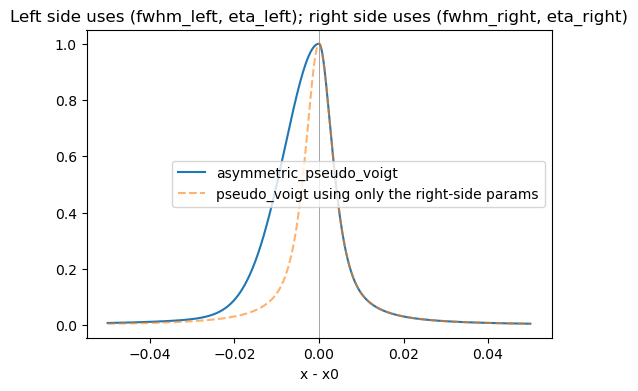

In [16]:
x = np.linspace(-0.05, 0.05, 2000)

# Deliberately very different left/right FWHM and eta to make the asymmetry obvious.
y_asym = asymmetric_pseudo_voigt(
    x, x0=0.0, amplitude=1.0,
    fwhm_right=0.008, eta_left=0.2,
    fwhm_left=0.02, eta_right=0.8,
)
y_sym_right = pseudo_voigt(x, 0.0, 1.0, 0.008, 0.8)  # what the right side alone would look like, symmetric

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y_asym, label="asymmetric_pseudo_voigt")
ax.plot(x, y_sym_right, "--", label="pseudo_voigt using only the right-side params", alpha=0.6)
ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlabel("x - x0")
ax.set_title("Left side uses (fwhm_left, eta_left); right side uses (fwhm_right, eta_right)")
ax.legend()
plt.show()

**Parameter order gotcha, worth seeing directly rather than just reading about it:**
the 6-parameter convention is
`[x0, amplitude, fwhm_right, eta_left, fwhm_left, eta_right]` — note that
`eta_left` (index 3) and `fwhm_left` (index 4) are *not* adjacent to each
other in a way that groups by side. This is confirmed correct against the
original tool's real output (see `AUDIT.md` §3, §9), not a design choice
made here — don't "fix" the ordering without re-running the parity test in
`tests/test_profiles.py`.

## 3. The Kα1/Kα2 doublet

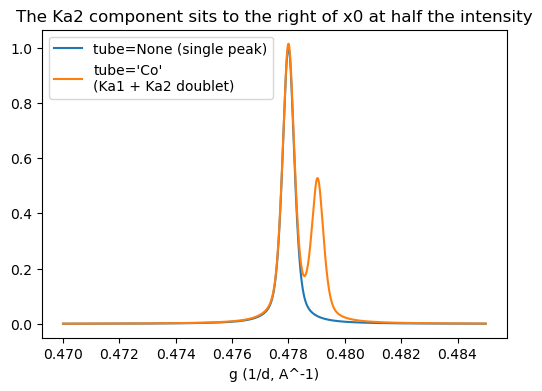

In [17]:
x = np.linspace(0.47, 0.485, 4000)
params = np.array([0.478, 1.0, 0.0005, 0.5, 0.0005, 0.5])  # x0, amplitude, fwhm_r, eta_l, fwhm_l, eta_r

single = evaluate_peak(x, params, tube=None)
doublet = evaluate_peak(x, params, tube="Co")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, single, label="tube=None (single peak)")
ax.plot(x, doublet, label="tube='Co'\n(Ka1 + Ka2 doublet)")
ax.set_xlabel("g (1/d, A^-1)")
ax.legend()
ax.set_title("The Ka2 component sits to the right of x0 at half the intensity")
plt.show()

A tube selects the matching X-ray wavelength pair. `tube=None` represents
single-wavelength data, including neutron diffraction, without a Kα doublet.

## 4. Real parity check: the original SS316 neutron fit

In [18]:
from pathlib import Path
from dippa.io.matlab_io import load_matlab_samples

sample = load_matlab_samples(Path("../data/SSnew_interpBCG_fit.mat"))[0]
valid = np.all(sample.aa[[0, 2, 4], :-1] > 0, axis=0)
aa = np.column_stack([sample.aa[:, :-1][:, valid], sample.aa[:, -1]])
x_real, y_real = sample.data[:, 0], sample.data[:, 1]

print(f"{aa.shape[1] - 1} peaks, {len(x_real)} measured points")

10 peaks, 11651 measured points


In [19]:
print("Provenance: SS316 neutron diffraction; phase id Steel_Neutron; a = 3.6 Å")
print("Neutron data have no X-ray Kα doublet, so tube=None.")

Provenance: SS316 neutron diffraction; phase id Steel_Neutron; a = 3.6 Å
Neutron data have no X-ray Kα doublet, so tube=None.


In [20]:
model = evaluate_pattern(x_real, aa, tube=None)

def r_squared(y, model):
    ss_res = np.sum((y - model) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

print(f"R^2: {r_squared(y_real, model):.4f}")

R^2: 0.8466


This saved fit is from the SS316 neutron dataset (`Steel_Neutron`, $a=3.6$ Å).
Its provenance resolves the apparent no-doublet mystery: a neutron pattern has
no X-ray Kα1/Kα2 construction, irrespective of stale `instr`/`alpha2` fields
in the MATLAB sample struct. The small `reference_fit.mat` and
`reference_data.mat` copies remain pytest fixtures only; examples load the named
source file through `dippa.io.matlab_io`.

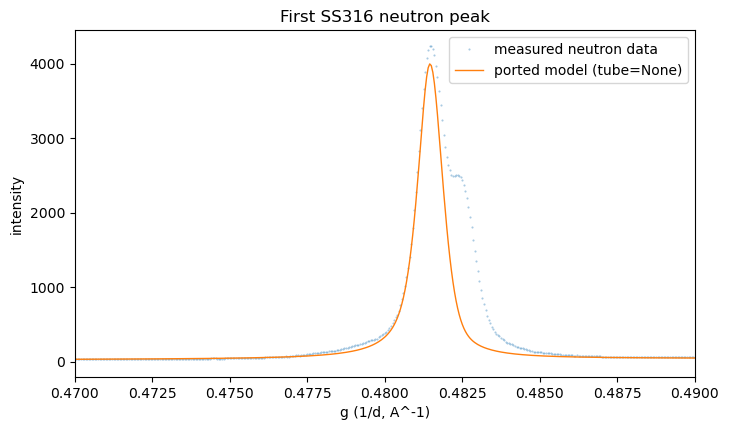

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_real, y_real, ".", markersize=1, alpha=0.4, label="measured neutron data")
ax.plot(x_real, model, linewidth=1, label="ported model (tube=None)")
ax.set_xlim(0.47, 0.49)
ax.set_xlabel("g (1/d, A^-1)")
ax.set_ylabel("intensity")
ax.set_title("First SS316 neutron peak")
ax.legend()
plt.show()

The single-component model tracks the real noisy neutron data closely across
the whole pattern, not just this first peak.

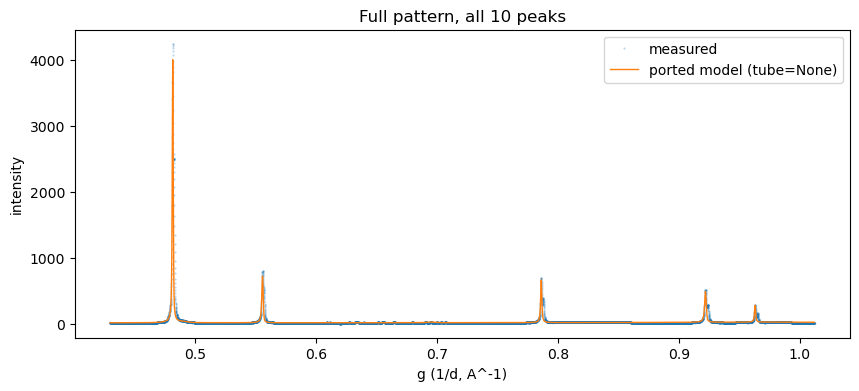

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_real, y_real, ".", markersize=1, alpha=0.3, label="measured")
ax.plot(x_real, model, linewidth=1, label="ported model (tube=None)")
ax.set_xlabel("g (1/d, A^-1)")
ax.set_ylabel("intensity")
ax.set_title("Full pattern, all 10 peaks")
ax.legend()
plt.show()

## 5. From a crystal structure to an example peak pattern

`Phase` turns a crystal structure and its unit-cell parameter(s) into allowed
reflections, d-spacings, and reciprocal positions $g=1/d$. FCC and BCC use
one cubic parameter $a$; HCP uses $a$ and $c$. The controls below recompute
the first eight allowed reflections and place an example pseudo-Voigt at
each position.

The peak heights are deliberately illustrative. They are not calculated
structure-factor intensities, so this plot teaches peak positions and indexing
rather than predicting a material's measured intensity ratios. HCP labels use
the compact Miller-Bravais dot form used elsewhere in Dippa, such as `10.0`.

In [23]:
from dippa.structure import Phase, format_hkil, generate_reflections, reciprocal_g


def plot_structure_pattern(cstruct="FCC", a=3.52, c=4.6835, n_peaks=8):
    """Plot illustrative pseudo-Voigts at a phase's first allowed reflections."""
    phase = Phase(cstruct, a=a, c=c if cstruct == "HCP" else None)
    reflections = generate_reflections(phase, max_index=8, limit=n_peaks)
    positions = np.array([reciprocal_g(phase, hkl) for hkl in reflections])

    span = np.ptp(positions)
    margin = max(0.04, 0.08 * span)
    g = np.linspace(max(0.0, positions[0] - margin), positions[-1] + margin, 6000)
    amplitudes = np.linspace(1.0, 0.55, len(reflections))
    width = max(0.003, 0.006 * span)
    components = [
        pseudo_voigt(g, position, amplitude, width, eta=0.45)
        for position, amplitude in zip(positions, amplitudes)
    ]
    pattern = np.sum(components, axis=0)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(g, pattern, color="tab:blue", linewidth=1.5)
    ax.vlines(positions, 0, amplitudes, color="0.65", linewidth=0.8, alpha=0.7)
    for hkl, position, amplitude in zip(reflections, positions, amplitudes):
        ax.annotate(
            format_hkil(hkl, phase.cstruct),
            (position, amplitude),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )
    lattice = f"a={phase.a:.4g} Å" + (f", c={phase.c:.4g} Å" if phase.c else "")
    ax.set(title=f"{phase.cstruct}: illustrative pattern ({lattice})", xlabel="g = 1/d (Å⁻¹)", ylabel="illustrative intensity")
    ax.set_ylim(bottom=0)
    ax.grid(axis="x", alpha=0.15)
    plt.show()


In [24]:

import ipywidgets as widgets
from IPython.display import display

structure_control = widgets.Dropdown(options=["FCC", "BCC", "HCP"], value="FCC", description="Structure")
a_control = widgets.FloatSlider(value=3.52, min=2.0, max=6.0, step=0.01, description="a (A)", continuous_update=False)
c_control = widgets.FloatSlider(value=4.6835, min=2.0, max=10.0, step=0.01, description="c (A)", continuous_update=False)

def show_hcp_c(change=None):
    c_control.layout.display = "" if structure_control.value == "HCP" else "none"

structure_control.observe(show_hcp_c, names="value")
show_hcp_c()
controls = widgets.HBox([structure_control, a_control, c_control])
output = widgets.interactive_output(
    plot_structure_pattern,
    {"cstruct": structure_control, "a": a_control, "c": c_control},
)
display(controls, output)


Output()